# 🕒 Actividad 02: Codificación Cíclica del Tiempo y Coordenadas NASA
---
**Módulo 2: Feature Engineering para LSTM**

Este notebook implementa la transformación de variables temporales en representaciones cíclicas (seno/coseno) y la integración de coordenadas geográficas. Estos pasos son críticos para que el modelo **LSTM-Attention** capture correctamente la estacionalidad agrícola y la proximidad espacial de las provincias.

## 🎯 Objetivos
1. **Codificación Cíclica**: Transformar meses y trimestres para eliminar saltos artificiales entre diciembre (12) y enero (1).
2. **Coordenadas NASA**: Asegurar que cada registro tenga su latitud y longitud para que el modelo aprenda patrones climáticos regionales.
3. **Validación Visual**: Confirmar que la transformación circular se realizó correctamente.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración estética
sns.set_theme(style='whitegrid', palette='viridis')
%matplotlib inline

# Rutas
INPUT_FILE = '../../data/processed/master_dataset_fase1.csv'
OUTPUT_FILE = '../../data/processed/master_dataset_fase2_multivariado.csv'

if not os.path.exists(INPUT_FILE):
    # Intentamos con v2 si existe
    INPUT_FILE = '../../data/processed/master_dataset_fase1_v2.csv'

print(f"Cargando dataset desde: {INPUT_FILE}")

Cargando dataset desde: ../../data/processed/master_dataset_fase1.csv


## 1. Carga de Datos
Leemos el dataset generado en la Fase 1 que integra MIDAGRI, INDECI y NASA.

In [2]:
df = pd.read_csv(INPUT_FILE)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head(2)

Dataset cargado: 5880 filas, 20 columnas


,fecha_evento,departamento,provincia,produccion_t,precio_chacra_kg,num_emergencias,total_afectados,hectareas_cultivo_perdidas,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,lat,lon,month_sin,month_cos
0,2021-01,AMAZONAS,BAGUA,-0.197656,0.156650,0.360646,0.213194,-0.013941,-0.945428,-0.202610,0.434204,-0.029451,0.543854,0.554373,0.469032,0.204645,-5.638889,-78.531111,0.500000,0.866025
1,2021-02,AMAZONAS,BAGUA,-0.187033,-0.393473,0.360646,0.036943,-0.013941,-0.952026,-0.266286,0.392674,-0.478104,0.728646,1.284617,0.650497,0.074091,-5.638889,-78.531111,0.866025,0.500000


## 2. Integración de Coordenadas NASA

### ¿Para qué sirve este paso?
El modelo LSTM analiza secuencias temporales, pero no sabe qué provincias están cerca de otras. Al incluir `lat` y `lon`, le damos al modelo una **dimensión espacial**. Por ejemplo, Piura y Lambayeque comparten climas similares por su ubicación; las coordenadas permiten al modelo aprender esa relación.

In [3]:
# Diccionario de coordenadas por departamento (Centroide aproximado)
# Nota: Si se dispone de coordenadas provinciales exactas de NASA POWER, se pueden incluir aquí.
COORDS_DEPTO = {
    'AMAZONAS': (-6.2294, -77.8728),
    'ANCASH': (-9.5261, -77.5289),
    'APURIMAC': (-13.6339, -72.8814),
    'AREQUIPA': (-16.4090, -71.5375),
    'AYACUCHO': (-13.1588, -74.2239),
    'CAJAMARCA': (-7.1638, -78.5003),
    'CALLAO': (-12.0566, -77.1491),
    'CUSCO': (-13.5320, -71.9675),
    'HUANCAVELICA': (-12.7826, -74.9727),
    'HUANUCO': (-9.9306, -76.2422),
    'ICA': (-14.0678, -75.7286),
    'JUNIN': (-11.1582, -74.9962),
    'LA LIBERTAD': (-8.1091, -79.0285),
    'LAMBAYEQUE': (-6.7711, -79.8441),
    'LIMA': (-12.0464, -77.0428),
    'LORETO': (-3.7491, -73.2538),
    'MADRE DE DIOS': (-12.5933, -69.1891),
    'MOQUEGUA': (-17.1983, -70.9357),
    'PASCO': (-10.6865, -76.2625),
    'PIURA': (-5.1945, -80.6328),
    'PUNO': (-15.8422, -70.0199),
    'SAN MARTIN': (-6.5200, -76.3656),
    'TACNA': (-18.0146, -70.2536),
    'TUMBES': (-3.5669, -80.4515),
    'UCAYALI': (-8.3791, -74.5339)
}

# Rellenar coordenadas faltantes basándose en el departamento
def fill_coords(row):
    if pd.isna(row['lat']) or pd.isna(row['lon']):
        return COORDS_DEPTO.get(row['departamento'], (np.nan, np.nan))
    return row['lat'], row['lon']

# Aplicamos la función si las columnas existen, si no, las creamos
if 'lat' not in df.columns: df['lat'] = np.nan
if 'lon' not in df.columns: df['lon'] = np.nan

new_coords = df.apply(fill_coords, axis=1)
df['lat'] = [c[0] for c in new_coords]
df['lon'] = [c[1] for c in new_coords]

print(f"Coordenadas integradas. NaNs restantes: {df['lat'].isna().sum()}")

Coordenadas integradas. NaNs restantes: 0


## 3. Codificación Cíclica (Mes y Trimestre)

### ¿Por qué es necesaria?
Si usamos el mes como número (1, 2, ..., 12), el modelo cree que la distancia entre Diciembre (12) y Enero (1) es 11. Pero en la realidad, ¡están pegados! 

Usando la transformación **Seno y Coseno**, convertimos el tiempo en un círculo donde el 12 y el 1 quedan matemáticamente contiguos.

*   `month_sin = sin(2π * mes / 12)`
*   `month_cos = cos(2π * mes / 12)`
*   `quarter_sin = sin(2π * trimestre / 4)`
*   `quarter_cos = cos(2π * trimestre / 4)`

In [4]:
# 1. Asegurar formato fecha
df['fecha_evento'] = pd.to_datetime(df['fecha_evento'])

# 2. Extraer componentes
df['mes_num'] = df['fecha_evento'].dt.month
df['trimestre_num'] = df['fecha_evento'].dt.quarter

# 3. Transformación Cíclica del Mes
df['month_sin'] = np.sin(2 * np.pi * df['mes_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['mes_num'] / 12)

# 4. Transformación Cíclica del Trimestre
df['trimestre_sin'] = np.sin(2 * np.pi * df['trimestre_num'] / 4)
df['trimestre_cos'] = np.cos(2 * np.pi * df['trimestre_num'] / 4)

print("Codificación cíclica completada para Mes y Trimestre.")
df[['fecha_evento', 'month_sin', 'month_cos', 'trimestre_sin', 'trimestre_cos']].head()

Codificación cíclica completada para Mes y Trimestre.


,fecha_evento,month_sin,month_cos,trimestre_sin,trimestre_cos
0,2021-01-01,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
1,2021-02-01,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
2,2021-03-01,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
3,2021-04-01,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
4,2021-05-01,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


## 4. Visualización de los Resultados

### El "Reloj" del Tiempo
Si graficamos el Seno vs el Coseno, deberíamos ver un círculo perfecto. Esto confirma que el modelo ahora entiende que el tiempo es cíclico.

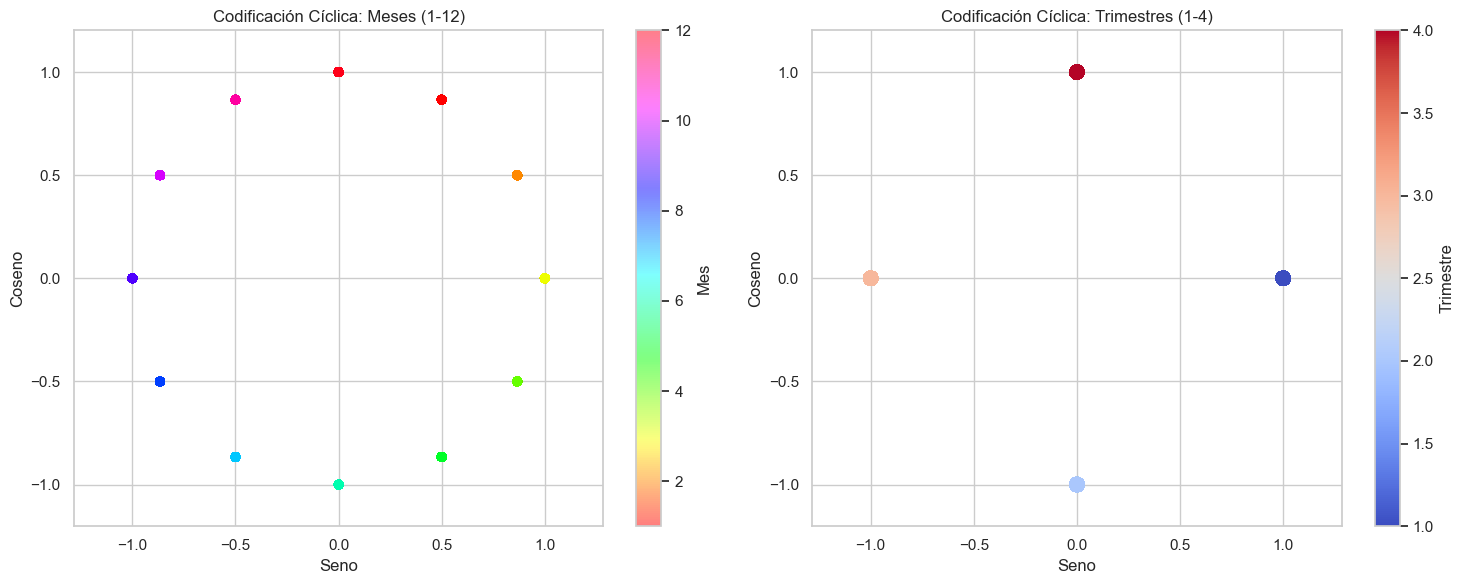

In [5]:
plt.figure(figsize=(15, 6))

# Subplot 1: Círculo de Meses
plt.subplot(1, 2, 1)
plt.scatter(df['month_sin'], df['month_cos'], c=df['mes_num'], cmap='hsv', alpha=0.5)
plt.title('Codificación Cíclica: Meses (1-12)', fontsize=12)
plt.xlabel('Seno')
plt.ylabel('Coseno')
plt.axis('equal')
plt.colorbar(label='Mes')

# Subplot 2: Círculo de Trimestres
plt.subplot(1, 2, 2)
plt.scatter(df['trimestre_sin'], df['trimestre_cos'], c=df['trimestre_num'], cmap='coolwarm', s=100)
plt.title('Codificación Cíclica: Trimestres (1-4)', fontsize=12)
plt.xlabel('Seno')
plt.ylabel('Coseno')
plt.axis('equal')
plt.colorbar(label='Trimestre')

plt.tight_layout()
plt.savefig('../../data/processed/visualizacion_ciclica.png')
plt.show()

## 5. Exportar Dataset Preparado para LSTM
Guardamos el dataset final de la Fase 2, que ahora incluye sentimiento NLP, coordenadas y tiempo cíclico.

In [6]:
# Eliminar columnas auxiliares si se desea (opcional)
# df = df.drop(columns=['mes_num', 'trimestre_num'])

# Guardar
df.to_csv(OUTPUT_FILE, index=False)
print(f"Dataset exportado exitosamente a: {OUTPUT_FILE}")
print(f"Columnas finales: {df.columns.tolist()}")

Dataset exportado exitosamente a: ../../data/processed/master_dataset_fase2_multivariado.csv
Columnas finales: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'hectareas_cultivo_perdidas', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'lat', 'lon', 'month_sin', 'month_cos', 'mes_num', 'trimestre_num', 'trimestre_sin', 'trimestre_cos']
